# AfriShop — Découvrir les données en clair



## 2. Les 6 fichiers en chiffres

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})

TABLES = ["orders", "order_lines", "customers", "products", "payments", "deliveries"]

def find_data_dir():
    # Dossier des CSV : variable d'environnement AFRISHOP_DATA_DIR, sinon emplacements usuels
    candidates = [os.environ.get("AFRISHOP_DATA_DIR", ""), "data/raw", "data", "projet data",
                  "../projet data", "projet 2 - Data ecommerce/projet data", "."]
    for c in candidates:
        if c and all((Path(c) / f"{t}.csv").exists() for t in TABLES):
            return Path(c)
    raise FileNotFoundError("CSV introuvables : définir AFRISHOP_DATA_DIR vers le dossier des 6 fichiers.")

DATA_DIR = find_data_dir()
FIG_DIR = Path(os.environ.get("AFRISHOP_REPORT_DIR", "reports/profiling_simple")) / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

def fr(n):
    # Nombre avec espace comme séparateur de milliers
    return f"{int(n):,}".replace(",", " ")

DATES = {"orders": ["order_date", "created_at", "updated_at"], "customers": ["registration_date"],
         "products": ["created_at", "updated_at"], "payments": ["payment_date"],
         "deliveries": ["shipped_at", "delivered_at"]}
data = {}
for t in TABLES:
    df = pd.read_csv(DATA_DIR / f"{t}.csv")
    for c in DATES.get(t, []):
        df[c] = pd.to_datetime(df[c], utc=True, errors="coerce").dt.tz_localize(None)
    data[t] = df
orders, lines, customers, products, payments, deliveries = (data[t] for t in TABLES)

ROLE = {
    "orders": "Les commandes (1 ligne = 1 commande)",
    "order_lines": "Le détail des articles de chaque commande",
    "customers": "Les clients inscrits",
    "products": "Le catalogue produits",
    "payments": "Les tentatives de paiement",
    "deliveries": "Le suivi des livraisons",
}
apercu = pd.DataFrame({
    "Contenu": [ROLE[t] for t in TABLES],
    "Lignes": [len(data[t]) for t in TABLES],
    "Colonnes": [data[t].shape[1] for t in TABLES],
    "Cases vides (%)": [100 * data[t].isna().to_numpy().mean() for t in TABLES],
}, index=TABLES)
display(apercu)
print("Période couverte par les commandes : du", orders["order_date"].min().date(), "au", orders["order_date"].max().date())

,Contenu,Lignes,Colonnes,Cases vides (%)
orders,Les commandes (1 ligne = 1 commande),52000,18,3.44
order_lines,Le détail des articles de chaque commande,107517,9,0.00
customers,Les clients inscrits,81200,14,0.00
products,Le catalogue produits,12000,15,0.00
payments,Les tentatives de paiement,46141,9,0.00
deliveries,Le suivi des livraisons,41218,9,3.14


Période couverte par les commandes : du 2025-05-01 au 2026-04-30


**Ce qu'on retient :** on dispose de six fichiers qui couvrent 12 mois d'activité. Les colonnes sont presque toutes complètes : les cases vides se limitent à des informations facultatives (par exemple le code promo quand il n'y en a pas, ou la date de livraison d'un colis pas encore livré).

## 3. Le bilan de santé des données

On a cherché les erreurs les plus courantes : lignes en double, références qui pointent vers rien, montants qui ne collent pas, dates impossibles. Chaque problème est compté, puis expliqué **en clair** avec la décision proposée.



In [2]:
# --- Vérifications (calculs) ----------------------------------------------------
orders_u = orders.drop_duplicates("order_id").reset_index(drop=True)          # commandes sans doublon
n_dup_orders = int(orders.duplicated("order_id").sum())

orphan_lines = ~lines["product_id"].isin(products["product_id"])              # article absent du catalogue
has_lines = orders_u["order_id"].isin(lines["order_id"])
calc_total = orders_u["subtotal_amount"] + orders_u["shipping_amount"] - orders_u["discount_amount"]
bad_total = (calc_total - orders_u["total_amount"]).abs() > 0.05               # total incohérent

captured = payments[payments["payment_status"] == "CAPTURED"].groupby("order_id")["payment_amount"].agg(["sum", "count"])
failed_ids = set(payments.loc[payments["payment_status"] == "FAILED", "order_id"])
cap = captured.join(orders_u.set_index("order_id")["total_amount"], how="inner")
cap["ratio"] = cap["sum"] / cap["total_amount"]
n_retry = int(cap.index.isin(failed_ids).sum())
n_partial = int((cap["ratio"] < 0.999).sum())
n_over = int((cap["ratio"] > 1.001).sum())

dl = deliveries.merge(orders_u[["order_id", "order_date", "delivery_address_zone", "order_status"]], on="order_id", how="left")
dl["jours_commande_livraison"] = (dl["delivered_at"] - dl["order_date"]).dt.total_seconds() / 86400
dl["jours_expedition_livraison"] = (dl["delivered_at"] - dl["shipped_at"]).dt.total_seconds() / 86400
delivered = dl["delivered_at"].notna()
n_late = int((dl["jours_commande_livraison"] >= 7).sum())
n_before_ship = int((dl["jours_expedition_livraison"] < 0).sum())

n_price0 = int((products["unit_price"] == 0).sum())
n_loss = int(((products["unit_cost"] > products["unit_price"]) & (products["unit_price"] > 0)).sum())
n_email_dup = int(customers["email_hash"].duplicated().sum())
n_id_collision = int(customers["customer_id"].duplicated().sum())

# --- Tableau récapitulatif --------------------------------------------------------
rows = [
    # (court, fichier, nombre, base, gravité, en clair, que faire)
    ("Commandes en double", "orders", n_dup_orders, len(orders), "Élevée",
     "La même commande apparaît deux fois (copies identiques).", "Garder une seule copie."),
    ("Articles vers un produit inexistant", "order_lines", int(orphan_lines.sum()), len(lines), "Élevée",
     "Un article commandé n'existe pas dans le catalogue (référence fantôme).", "Mettre en quarantaine ces lignes."),
    ("Total de commande incohérent", "orders", int(bad_total.sum()), len(orders_u), "Élevée",
     "Le total facturé ne correspond pas au calcul sous-total + livraison − remise.", "Mettre en quarantaine."),
    ("Paiement encaissé plusieurs fois", "payments", n_over, len(cap), "Élevée",
     "Une commande est encaissée 2 ou 3 fois.", "Vérifier avec le prestataire de paiement ; ne jamais additionner sans contrôle."),
    ("Clients en double (même e-mail)", "customers", n_email_dup, len(customers), "Élevée",
     "Le même client existe sous deux identifiants différents.", "Fusionner en un seul client."),
    ("Identifiant client partagé", "customers", n_id_collision, len(customers), "Élevée",
     "Un même identifiant est utilisé pour deux personnes différentes.", "Créer un identifiant technique unique."),
    ("Paiement partiel", "payments", n_partial, len(cap), "Moyenne",
     "Le montant encaissé est inférieur au total de la commande.", "Marquer la commande « partiellement payée »."),
    ("Paiement réessayé (échec puis succès)", "payments", n_retry, len(cap), "Moyenne",
     "Un premier paiement échoue, un second réussit.", "Garder le paiement réussi comme référence."),
    ("Livrée avant d'être expédiée", "deliveries", n_before_ship, int(delivered.sum()), "Moyenne",
     "La date de livraison est antérieure à la date d'expédition (impossible).", "Corriger ou mettre en quarantaine."),
    ("Produit à prix zéro", "products", n_price0, len(products), "Moyenne",
     "Un produit est affiché à 0.", "Signaler au métier ; mettre en quarantaine."),
    ("Produit vendu à perte", "products", n_loss, len(products), "Moyenne",
     "Le coût d'achat dépasse le prix de vente.", "Signaler au métier."),
    ("Livraison tardive (7 jours ou plus)", "deliveries", n_late, int(delivered.sum()), "À connaître",
     "Le colis arrive 7 à 21 jours après la commande.", "Normal : à conserver, et à mesurer."),
]
problemes = pd.DataFrame(rows, columns=["Problème", "Fichier", "Nombre", "Base", "Gravité", "En clair", "Que faire"])
problemes["Part (%)"] = 100 * problemes["Nombre"] / problemes["Base"]
display(problemes[["Problème", "Fichier", "Nombre", "Part (%)", "Gravité"]])

,Problème,Fichier,Nombre,Part (%),Gravité
0,Commandes en double,orders,1500,2.88,Élevée
1,Articles vers un produit inexistant,order_lines,2108,1.96,Élevée
2,Total de commande incohérent,orders,500,0.99,Élevée
3,Paiement encaissé plusieurs fois,payments,98,0.27,Élevée
4,Clients en double (même e-mail),customers,1200,1.48,Élevée
5,Identifiant client partagé,customers,10,0.01,Élevée
6,Paiement partiel,payments,320,0.88,Moyenne
7,Paiement réessayé (échec puis succès),payments,390,1.07,Moyenne
8,Livrée avant d'être expédiée,deliveries,1860,6.29,Moyenne
9,Produit à prix zéro,products,119,0.99,Moyenne


**Comment lire le graphique ci-dessous :** chaque barre est un problème. Plus elle est longue, plus le problème touche une grande **part** de son fichier. La couleur indique la **gravité** : rouge = à traiter en priorité, orange = à traiter, gris = simplement à connaître. Les nombres à droite donnent le nombre de lignes concernées.

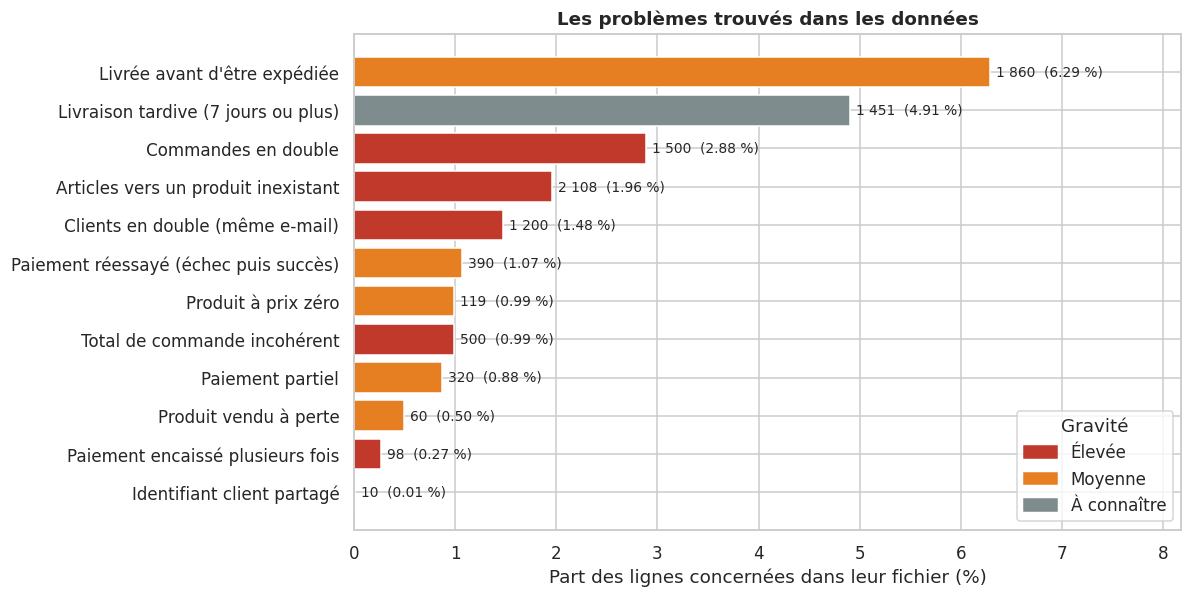

In [3]:
COULEUR = {"Élevée": "#c0392b", "Moyenne": "#e67e22", "À connaître": "#7f8c8d"}
plot_df = problemes.sort_values("Part (%)")
fig, ax = plt.subplots(figsize=(11, 5.6))
bars = ax.barh(plot_df["Problème"], plot_df["Part (%)"], color=plot_df["Gravité"].map(COULEUR))
for b, n, p in zip(bars, plot_df["Nombre"], plot_df["Part (%)"]):
    ax.text(b.get_width() + 0.06, b.get_y() + b.get_height() / 2, f"{fr(n)}  ({p:.2f} %)", va="center", fontsize=9)
ax.set_xlim(0, plot_df["Part (%)"].max() * 1.3)
ax.set(title="Les problèmes trouvés dans les données", xlabel="Part des lignes concernées dans leur fichier (%)", ylabel="")
ax.legend(handles=[Patch(color=c, label=g) for g, c in COULEUR.items()], title="Gravité", loc="lower right", frameon=True)
savefig("00_problemes_trouves")

**Ce qu'on retient :** aucun problème ne touche plus de 7 % d'un fichier, mais **les problèmes rouges faussent directement les chiffres d'affaires, les paiements et le nombre de clients** s'ils ne sont pas traités. Le détail et la décision proposée pour chacun figurent ci-dessous.

In [4]:
with pd.option_context("display.max_colwidth", None):
    display(problemes[["Problème", "En clair", "Que faire"]])
print("Précisions :")
print(f"- Les {fr(bad_total.sum())} commandes à total incohérent : {fr((bad_total & ~has_lines).sum())} n'ont aucun article associé (deux symptômes du même problème).")
print(f"- Les {fr(orphan_lines.sum())} articles fantômes touchent {fr(lines.loc[orphan_lines, 'order_id'].nunique())} commandes ; une fois retirés, le sous-total de ces commandes redevient exact.")
print(f"- Commandes distinctes une fois les doublons retirés : {fr(len(orders_u))} (sur {fr(len(orders))} lignes reçues).")
print(f"- Hash e-mail / téléphone : longueur {customers['email_hash'].str.len().iloc[0]} caractères au lieu de 64 attendus → ils devront être re-chiffrés avec un sel.")

,Problème,En clair,Que faire
0,Commandes en double,La même commande apparaît deux fois (copies identiques).,Garder une seule copie.
1,Articles vers un produit inexistant,Un article commandé n'existe pas dans le catalogue (référence fantôme).,Mettre en quarantaine ces lignes.
2,Total de commande incohérent,Le total facturé ne correspond pas au calcul sous-total + livraison − remise.,Mettre en quarantaine.
3,Paiement encaissé plusieurs fois,Une commande est encaissée 2 ou 3 fois.,Vérifier avec le prestataire de paiement ; ne jamais additionner sans contrôle.
4,Clients en double (même e-mail),Le même client existe sous deux identifiants différents.,Fusionner en un seul client.
5,Identifiant client partagé,Un même identifiant est utilisé pour deux personnes différentes.,Créer un identifiant technique unique.
6,Paiement partiel,Le montant encaissé est inférieur au total de la commande.,Marquer la commande « partiellement payée ».
7,Paiement réessayé (échec puis succès),"Un premier paiement échoue, un second réussit.",Garder le paiement réussi comme référence.
8,Livrée avant d'être expédiée,La date de livraison est antérieure à la date d'expédition (impossible).,Corriger ou mettre en quarantaine.
9,Produit à prix zéro,Un produit est affiché à 0.,Signaler au métier ; mettre en quarantaine.


Précisions :
- Les 500 commandes à total incohérent : 500 n'ont aucun article associé (deux symptômes du même problème).
- Les 2 108 articles fantômes touchent 2 070 commandes ; une fois retirés, le sous-total de ces commandes redevient exact.
- Commandes distinctes une fois les doublons retirés : 50 500 (sur 52 000 lignes reçues).
- Hash e-mail / téléphone : longueur 16 caractères au lieu de 64 attendus → ils devront être re-chiffrés avec un sel.


### Les données sont-elles utilisables ?

Oui, **après nettoyage**. La plus grande partie des lignes est saine ; on isole simplement le reste.

In [5]:
sains = pd.DataFrame({
    "Lignes exploitables": [int((~orphan_lines).sum()), int((~bad_total & has_lines).sum())],
    "Lignes totales": [len(lines), len(orders_u)],
}, index=["Articles de commande", "Commandes (sans doublon)"])
sains["Part saine (%)"] = 100 * sains["Lignes exploitables"] / sains["Lignes totales"]
display(sains)

,Lignes exploitables,Lignes totales,Part saine (%)
Articles de commande,105409,107517,98.04
Commandes (sans doublon),50000,50500,99.01


## 4. Ce que racontent les données

À partir d'ici, on regarde l'activité d'AfriShop. Les commandes en double sont retirées (on travaille sur les commandes **distinctes**). Les montants restent dans leur **devise locale** : on ne les additionne jamais entre pays, car 1 franc CFA n'est pas 1 cedi ni 1 naira.

### 4.1 L'activité dans le temps

**Comment lire ces graphiques :**
- *À gauche* : chaque barre est un mois ; ses couleurs montrent la part de chaque pays. Plus la barre est haute, plus il y a eu de commandes.
- *À droite* : la valeur des commandes de chaque devise, ramenée à **100 pour le premier mois**. Une courbe au-dessus de 100 signifie « plus qu'au premier mois ». On compare ainsi les évolutions sans mélanger les monnaies.

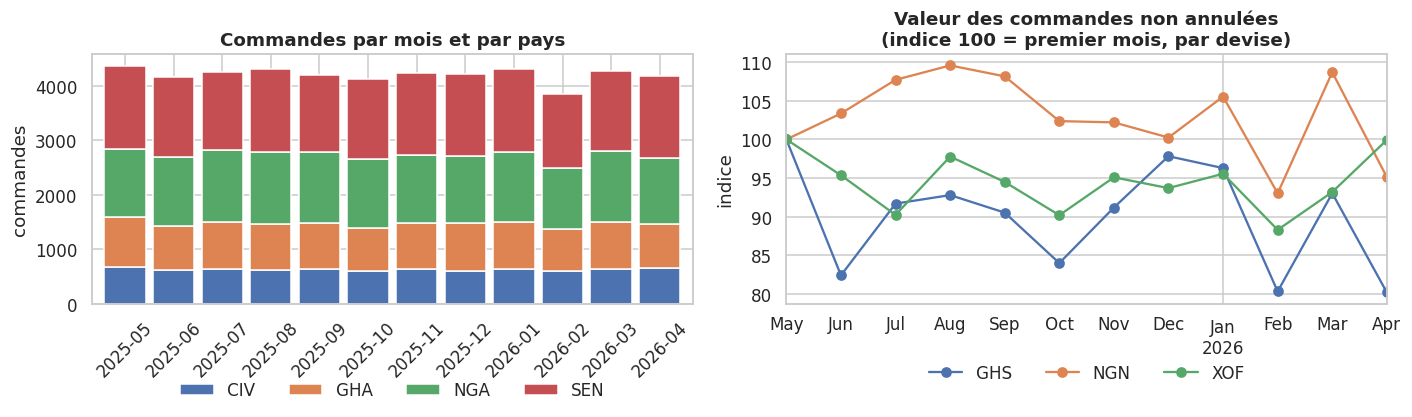

Commandes par mois : moyenne 4 208 · minimum 3 848 (2026-02) · maximum 4 369 (2025-05)


In [6]:
o = orders_u.copy()
o["month"] = o["order_date"].dt.to_period("M").dt.to_timestamp()
o["annulee"] = o["order_status"].eq("CANCELLED")

par_mois = o.groupby(["month", "country_code"]).size().unstack(fill_value=0)
par_mois.index = par_mois.index.strftime("%Y-%m")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
par_mois.plot(kind="bar", stacked=True, ax=ax[0], width=0.85)
ax[0].tick_params(axis="x", rotation=45)
ax[0].set(title="Commandes par mois et par pays", xlabel="", ylabel="commandes")
ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)

valeur = o[~o["annulee"]].groupby(["month", "currency"])["total_amount"].sum().unstack()
(valeur / valeur.iloc[0] * 100).plot(ax=ax[1], marker="o")
ax[1].set(title="Valeur des commandes non annulées\n(indice 100 = premier mois, par devise)", xlabel="", ylabel="indice")
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
savefig("01_dynamique_mensuelle")
print(f"Commandes par mois : moyenne {fr(par_mois.sum(axis=1).mean())} · minimum {fr(par_mois.sum(axis=1).min())} ({par_mois.sum(axis=1).idxmin()}) · maximum {fr(par_mois.sum(axis=1).max())} ({par_mois.sum(axis=1).idxmax()})")

**Ce qu'on retient :** le volume de commandes est **stable** d'un mois à l'autre, avec un léger creux en février (mois plus court). On ne voit **pas de croissance** sur les 12 mois. Le Sénégal et le Nigeria pèsent le plus. La valeur des commandes varie de quelques dizaines de pour cent d'un mois à l'autre, sans tendance nette.

**Comment lire le graphique suivant :** chaque case est un créneau (un jour de la semaine, une heure). Plus la case est **foncée**, plus il y a eu de commandes sur ce créneau. Les heures sont en **UTC** (heure de référence mondiale, proche de l'heure de Dakar et d'Accra).

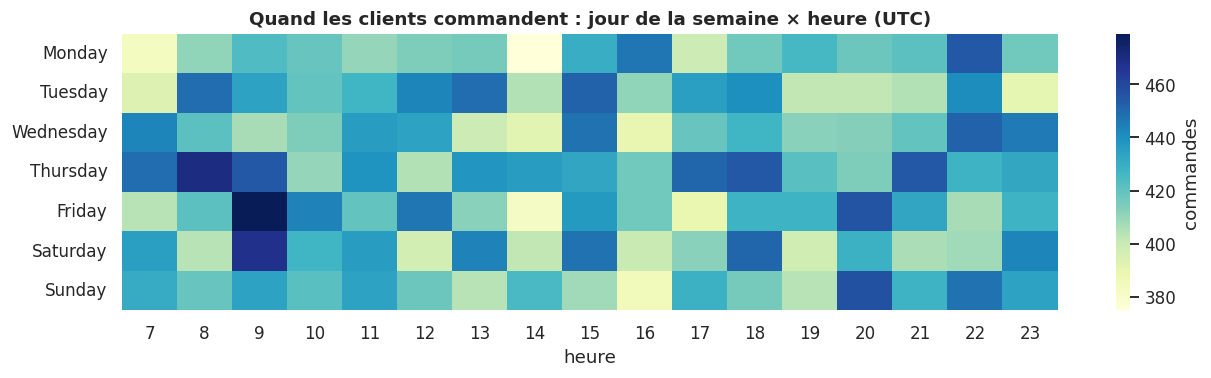

Commandes passées entre 7 h et 23 h (UTC) · par créneau : de 375 à 479


In [7]:
o["jour"] = o["order_date"].dt.day_name()
o["heure"] = o["order_date"].dt.hour
ordre_jours = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
carte = o.pivot_table(index="jour", columns="heure", values="order_id", aggfunc="count").reindex(ordre_jours)
fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(carte, cmap="YlGnBu", ax=ax, cbar_kws={"label": "commandes"})
ax.set(title="Quand les clients commandent : jour de la semaine × heure (UTC)", xlabel="heure", ylabel="")
savefig("02_saisonnalite_heure")
print(f"Commandes passées entre {int(o['heure'].min())} h et {int(o['heure'].max())} h (UTC) · par créneau : de {fr(carte.min().min())} à {fr(carte.max().max())}")

**Ce qu'on retient :** il n'y a **aucune commande la nuit** (aucune entre minuit et 7 h) et, en journée, **pas de pic marqué** : tous les jours et toutes les heures se ressemblent. Dans une vraie marketplace, on s'attendrait à des pics le soir ou le week-end. C'est un signe que les données sont **synthétiques** (fabriquées pour l'exercice).

### 4.2 Qui commande, comment et où ?

**Comment lire ces graphiques :**
- *En haut à gauche* : combien de commandes dans chaque état (livrée, annulée, en cours…).
- *En haut à droite* : par quel canal les clients commandent (application mobile, site web, WhatsApp…).
- *En bas* : pour chaque pays, une barre qui fait **100 %** et qui se découpe en zones de livraison (à gauche) ou en canaux de vente (à droite).

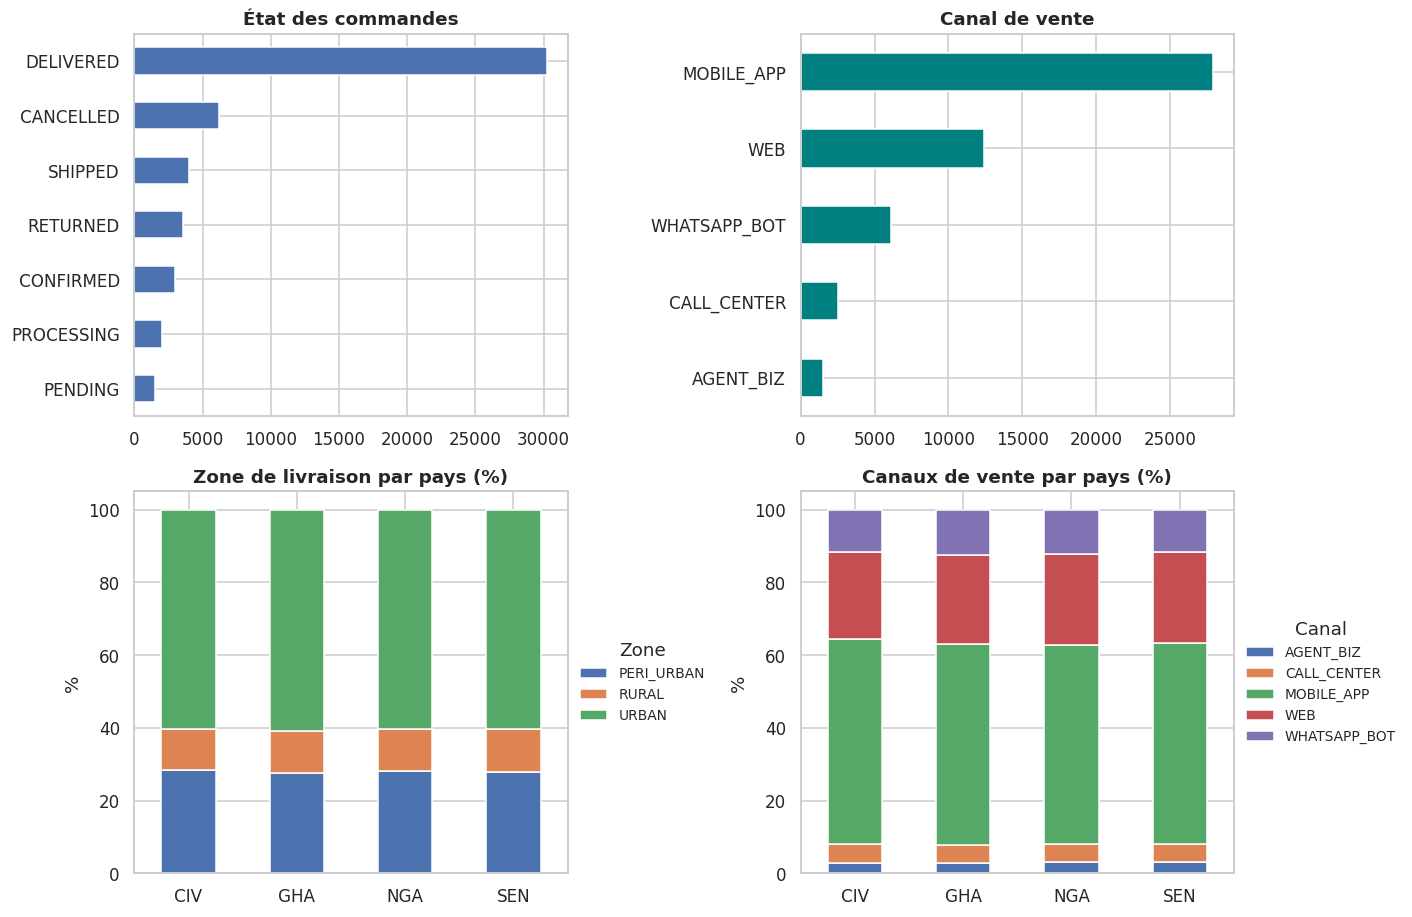

Commandes livrées : 59.9 % · annulées : 12.2 % · retournées : 7.0 %
Application mobile : 55.3 % · site web : 24.6 %
Zone urbaine : 60.4 % · péri-urbaine : 28.0 % · rurale : 11.6 %


In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8.5))
o["order_status"].value_counts().plot(kind="barh", ax=ax[0, 0]); ax[0, 0].invert_yaxis()
ax[0, 0].set(title="État des commandes", ylabel="")
o["channel"].value_counts().plot(kind="barh", ax=ax[0, 1], color="teal"); ax[0, 1].invert_yaxis()
ax[0, 1].set(title="Canal de vente", ylabel="")
(pd.crosstab(o["country_code"], o["delivery_address_zone"], normalize="index") * 100).plot(kind="bar", stacked=True, ax=ax[1, 0])
ax[1, 0].set(title="Zone de livraison par pays (%)", xlabel="", ylabel="%"); ax[1, 0].tick_params(axis="x", rotation=0)
ax[1, 0].legend(title="Zone", loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)
(pd.crosstab(o["country_code"], o["channel"], normalize="index") * 100).plot(kind="bar", stacked=True, ax=ax[1, 1])
ax[1, 1].set(title="Canaux de vente par pays (%)", xlabel="", ylabel="%"); ax[1, 1].tick_params(axis="x", rotation=0)
ax[1, 1].legend(title="Canal", loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)
savefig("03_structure_commandes")

pct = lambda s, v: 100 * (s == v).mean()
print(f"Commandes livrées : {pct(o['order_status'], 'DELIVERED'):.1f} % · annulées : {pct(o['order_status'], 'CANCELLED'):.1f} % · retournées : {pct(o['order_status'], 'RETURNED'):.1f} %")
print(f"Application mobile : {pct(o['channel'], 'MOBILE_APP'):.1f} % · site web : {pct(o['channel'], 'WEB'):.1f} %")
print(f"Zone urbaine : {pct(o['delivery_address_zone'], 'URBAN'):.1f} % · péri-urbaine : {pct(o['delivery_address_zone'], 'PERI_URBAN'):.1f} % · rurale : {pct(o['delivery_address_zone'], 'RURAL'):.1f} %")

**Ce qu'on retient :** environ **6 commandes sur 10 sont livrées**, une sur huit est **annulée** et 7 % sont **retournées** (le reste est en cours de traitement). L'**application mobile** est le premier canal de vente (un peu plus d'une commande sur deux). Point d'attention : la répartition par zone et par canal est **presque identique dans les quatre pays**, ce qui est rarement le cas dans la réalité.

**Comment lire le graphique suivant :** une « boîte » résume la majorité des commandes d'une devise : le trait au milieu est la **médiane** (la commande « typique »), la boîte contient la moitié des commandes, et les points à droite sont les commandes exceptionnellement grosses. L'axe est en **échelle logarithmique** (chaque graduation vaut 10 fois la précédente) pour que les petites et les grosses commandes tiennent sur le même graphique.

,commandes,moyenne,25 %,médiane,75 %,95 %,max
currency,,,,,,,
GHS,"10,084.00","116,276.45","45,529.85","90,068.73","163,830.97","300,276.72","676,827.02"
NGN,"15,157.00","116,209.54","45,642.18","89,801.44","162,893.93","305,004.38","758,630.06"
XOF,"25,259.00","117,112.95","46,058.15","89,758.79","162,520.55","310,623.56","748,740.68"


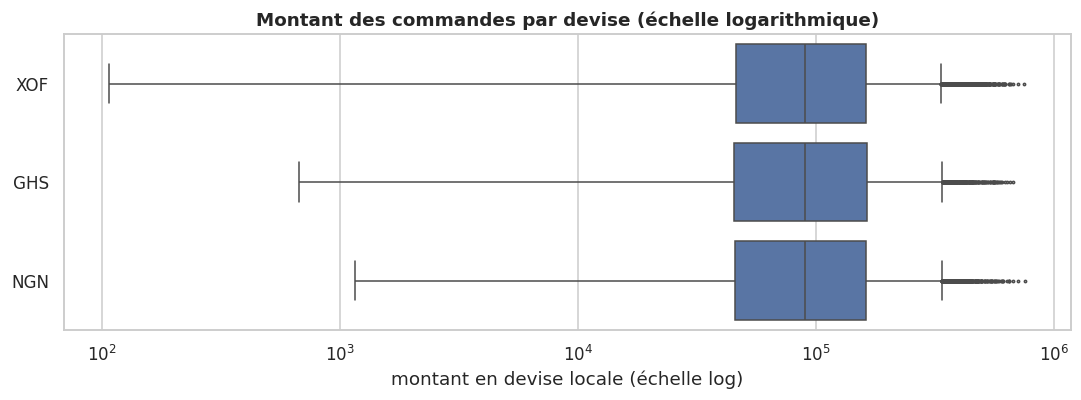

In [9]:
display(o.groupby("currency")["total_amount"].describe(percentiles=[.25, .5, .75, .95]).rename(
    columns={"count": "commandes", "mean": "moyenne", "50%": "médiane", "25%": "25 %", "75%": "75 %", "95%": "95 %"})[["commandes", "moyenne", "25 %", "médiane", "75 %", "95 %", "max"]])
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.boxplot(data=o, x="total_amount", y="currency", orient="h", fliersize=1.5, ax=ax)
ax.set_xscale("log")
ax.set(title="Montant des commandes par devise (échelle logarithmique)", xlabel="montant en devise locale (échelle log)", ylabel="")
savefig("04_montants_par_devise")

**Ce qu'on retient :** les trois devises ont **quasiment la même distribution**, avec une commande typique d'environ **90 000** partout. Or 90 000 francs CFA, 90 000 cedis et 90 000 nairas ne valent pas du tout la même chose. Autre signe que les montants sont **synthétiques** : il ne faut donc **pas** les lire comme de vraies valeurs commerciales, et **jamais** les additionner entre pays sans conversion.

### 4.3 Ce qu'on achète

**Comment lire ces graphiques :**
- *À gauche* : combien de commandes contiennent 1, 2, 3… articles différents.
- *Au milieu* : combien d'unités du même article sont prises sur une ligne (1, 2, 3 ou 4).
- *À droite* : le nombre total d'unités vendues par catégorie de produit.

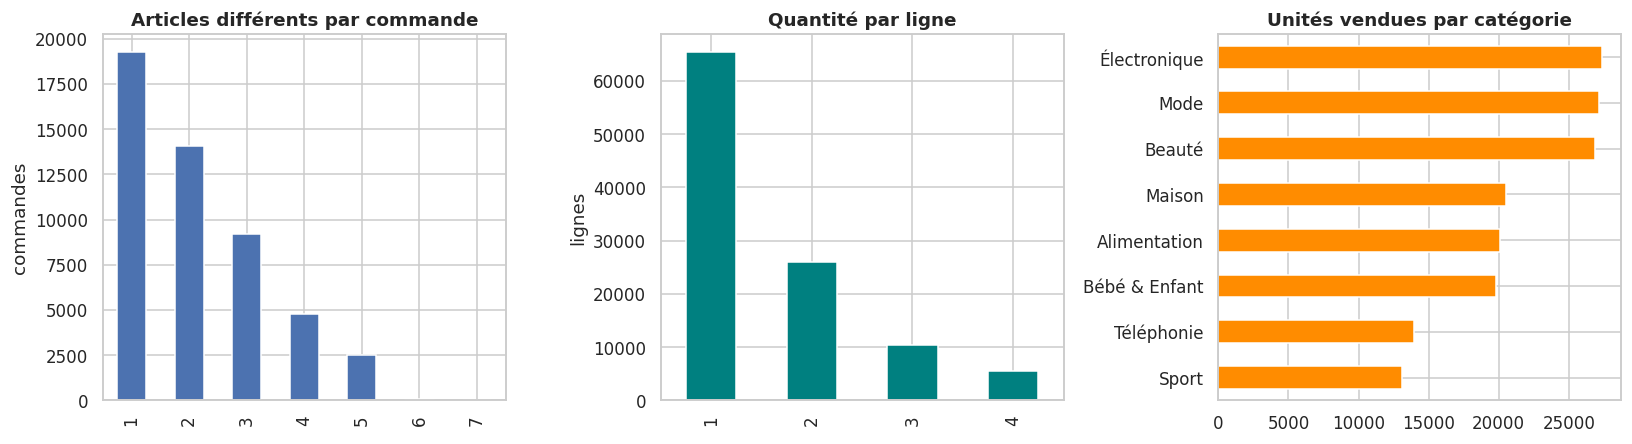

Panier moyen : 2.2 articles différents et 3.4 unités par commande
Produits du catalogue jamais commandés : 2 528 sur 12 000 (21 %)


In [10]:
valides = lines.loc[~orphan_lines].merge(products[["product_id", "category_name"]], on="product_id", how="left")
valides = valides.merge(orders_u[["order_id", "country_code"]], on="order_id", how="left")
panier = lines.groupby("order_id").agg(articles=("order_line_id", "count"), unites=("quantity", "sum"))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
panier["articles"].value_counts().sort_index().plot(kind="bar", ax=ax[0]); ax[0].set(title="Articles différents par commande", xlabel="", ylabel="commandes")
lines["quantity"].value_counts().sort_index().plot(kind="bar", ax=ax[1], color="teal"); ax[1].set(title="Quantité par ligne", xlabel="", ylabel="lignes")
valides.groupby("category_name")["quantity"].sum().sort_values().plot(kind="barh", ax=ax[2], color="darkorange"); ax[2].set(title="Unités vendues par catégorie", ylabel="")
savefig("05_panier_catalogue")
print(f"Panier moyen : {panier['articles'].mean():.1f} articles différents et {panier['unites'].mean():.1f} unités par commande")
print(f"Produits du catalogue jamais commandés : {fr((~products['product_id'].isin(lines['product_id'])).sum())} sur {fr(len(products))} ({100*(~products['product_id'].isin(lines['product_id'])).mean():.0f} %)")

**Ce qu'on retient :** les clients achètent **peu d'articles à la fois** : la commande la plus courante contient un seul article, et la quantité la plus courante est 1. Trois catégories dominent en volume : **Électronique, Mode et Beauté**. **Sport** et **Téléphonie** ferment la marche. Environ un produit sur cinq du catalogue n'a jamais été commandé.

**Comment lire le graphique suivant :** chaque ligne est un pays et chaque colonne une catégorie. Le nombre dans une case est la **part** de cette catégorie dans les unités vendues du pays (chaque ligne totalise 100 %). Plus la case est **foncée**, plus la catégorie pèse.

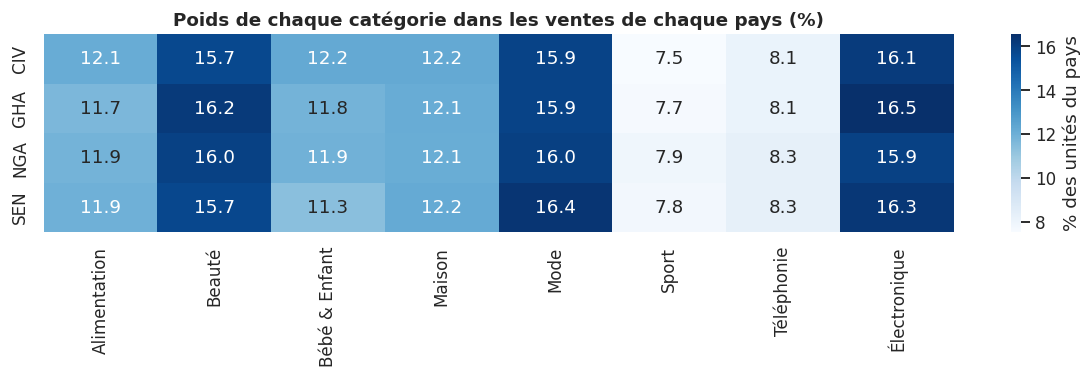

In [11]:
part = pd.crosstab(valides["country_code"], valides["category_name"], values=valides["quantity"], aggfunc="sum", normalize="index") * 100
fig, ax = plt.subplots(figsize=(11, 3.6))
sns.heatmap(part, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% des unités du pays"})
ax.set(title="Poids de chaque catégorie dans les ventes de chaque pays (%)", xlabel="", ylabel="")
savefig("06_mix_categories_pays")

**Ce qu'on retient :** les quatre pays achètent **exactement la même chose dans les mêmes proportions** (Beauté, Mode et Électronique autour de 16 % chacune, Sport autour de 8 %). Dans un vrai marché, les goûts varient d'un pays à l'autre : ici, **aucune différence** ne ressort, ce qui confirme encore le caractère synthétique.

### 4.4 Les paiements

**Comment lire ces graphiques :** ce sont deux tableaux colorés, où chaque nombre est un pourcentage.
- *À gauche* : dans chaque pays (ligne), quelle part des paiements passe par chaque mode (colonne). **Mobile Money** désigne le paiement depuis un téléphone (Orange Money, Wave, MTN MoMo). **COD** veut dire *cash on delivery*, le paiement en espèces à la livraison.
- *À droite* : pour chaque mode de paiement (ligne), le résultat des paiements (colonne) : encaissé (**CAPTURED**), échoué (**FAILED**), en attente, etc.

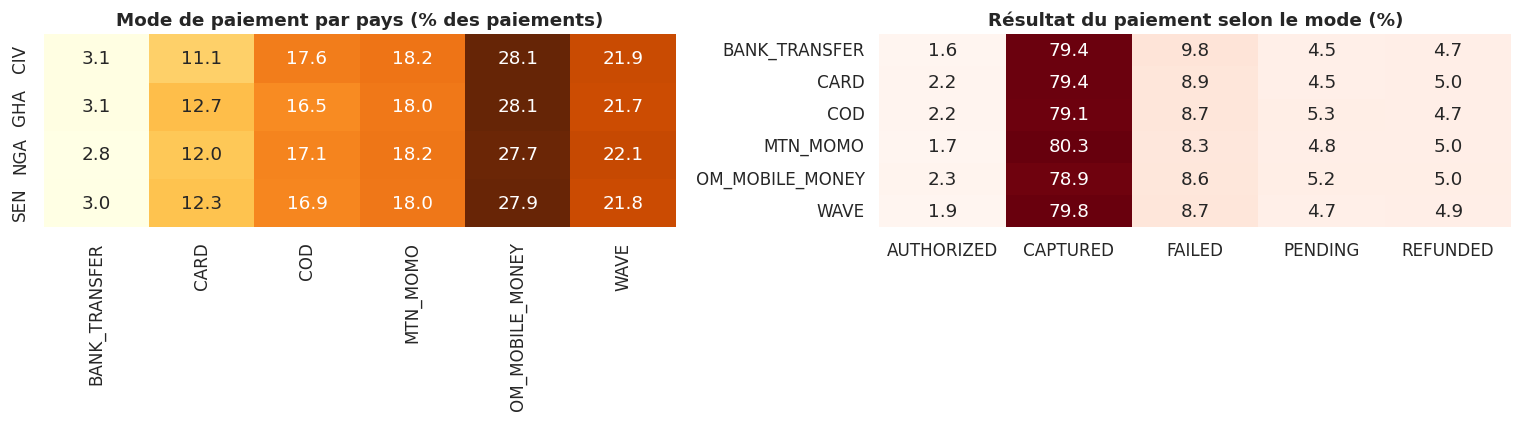

Paiements encaissés : 79.5 % · échoués : 8.7 %


In [12]:
pp = payments.merge(orders_u[["order_id", "country_code"]], on="order_id", how="left")
mix = pd.crosstab(pp["country_code"], pp["payment_method"], normalize="index") * 100
statut = pd.crosstab(pp["payment_method"], pp["payment_status"], normalize="index") * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(mix, annot=True, fmt=".1f", cmap="YlOrBr", ax=ax[0], cbar=False)
ax[0].set(title="Mode de paiement par pays (% des paiements)", xlabel="", ylabel="")
sns.heatmap(statut, annot=True, fmt=".1f", cmap="Reds", ax=ax[1], cbar=False)
ax[1].set(title="Résultat du paiement selon le mode (%)", xlabel="", ylabel="")
savefig("07_paiements")
print(f"Paiements encaissés : {100*(payments['payment_status']=='CAPTURED').mean():.1f} % · échoués : {100*(payments['payment_status']=='FAILED').mean():.1f} %")

**Ce qu'on retient :** environ **4 paiements sur 5 sont encaissés** et environ **9 % échouent**, quel que soit le mode de paiement. Orange Money est le mode le plus utilisé, devant Wave. Comme pour le reste, la répartition est **identique dans les quatre pays**, alors qu'en réalité chaque opérateur Mobile Money est fort dans certains pays seulement (Wave au Nigeria, par exemple, n'aurait pas de sens).

### 4.5 Les livraisons

**Comment lire ces graphiques :**
- *À gauche* : combien de livraisons ont pris 2 jours, 3 jours, etc. entre la commande et l'arrivée du colis. La ligne rouge marque **7 jours**, seuil à partir duquel on parle de livraison **tardive**.
- *À droite* : le temps entre l'expédition et l'arrivée. Tout ce qui se trouve à gauche de la ligne rouge (zéro) est **impossible** : le colis serait arrivé avant d'être parti.

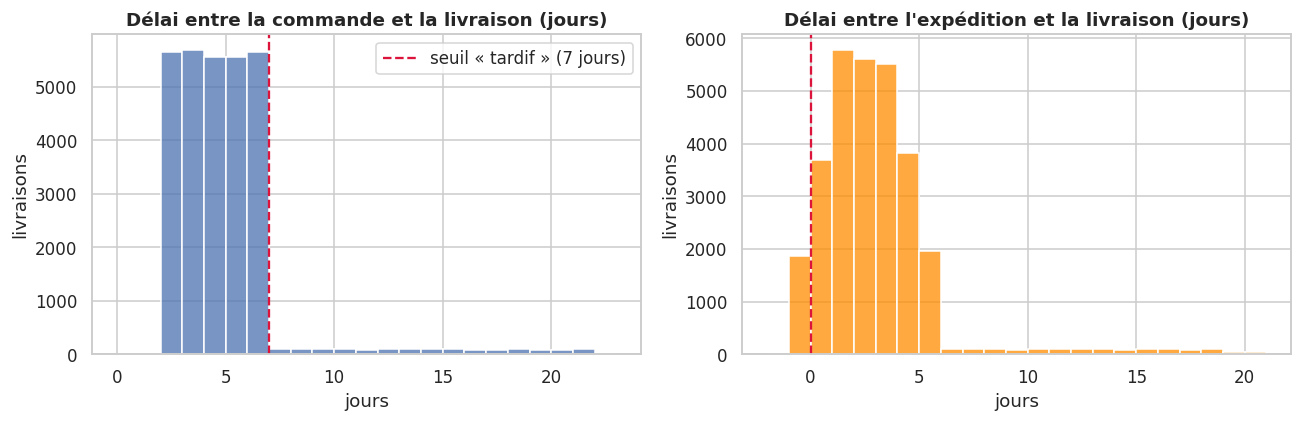

Délai médian commande → livraison : 4 jours · maximum : 21 jours
Livraisons tardives (7 jours ou plus) : 4.9 % · livraisons datées avant l'expédition : 1 860 (6.3 %)


In [13]:
fait = dl[delivered]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(fait["jours_commande_livraison"], bins=range(0, 24), ax=ax[0])
ax[0].axvline(7, color="crimson", ls="--", label="seuil « tardif » (7 jours)")
ax[0].set(title="Délai entre la commande et la livraison (jours)", xlabel="jours", ylabel="livraisons"); ax[0].legend()
sns.histplot(fait["jours_expedition_livraison"], bins=np.arange(-2, 22), ax=ax[1], color="darkorange")
ax[1].axvline(0, color="crimson", ls="--")
ax[1].set(title="Délai entre l'expédition et la livraison (jours)", xlabel="jours", ylabel="livraisons")
savefig("08_delais_livraison")
print(f"Délai médian commande → livraison : {fait['jours_commande_livraison'].median():.0f} jours · maximum : {fait['jours_commande_livraison'].max():.0f} jours")
print(f"Livraisons tardives (7 jours ou plus) : {100*n_late/len(fait):.1f} % · livraisons datées avant l'expédition : {fr(n_before_ship)} ({100*n_before_ship/len(fait):.1f} %)")

**Ce qu'on retient :** une livraison prend en général **quatre jours**. Environ **5 % des colis** arrivent avec 7 à 21 jours de retard : c'est prévu dans le sujet et on doit savoir les rattacher à la bonne commande quand ils arrivent. En revanche, **plus de 6 % des livraisons sont datées avant leur expédition** : c'est une erreur de données à corriger.

**Comment lire ces graphiques :**
- *À gauche* : pour chaque zone de livraison, une « boîte » résume la durée des livraisons (le trait au milieu est la durée typique ; les ronds sont les cas très longs).
- *À droite* : combien de livraisons dans chaque état (livrée, en transit, échouée…).

,livraisons,echec_pct,cout_moyen,delai_median_jours
carrier,,,,
YANGO_DELIVERY,5227,5.41,"3,115.69",4.00
BOLT_DELIVERY,5199,5.02,"3,159.98",4.00
GLOVO,5176,4.71,"3,165.01",4.00
CHRONOPOST_AFRIQUE,5168,4.90,"3,148.34",4.00
DHL,5162,5.48,"3,160.22",4.00
INTERNAL_FLEET,5138,4.81,"3,142.71",4.00
AFRIPOST,5124,4.90,"3,178.94",4.00
JUMIA_LOGISTICS,5024,5.00,"3,132.12",4.00


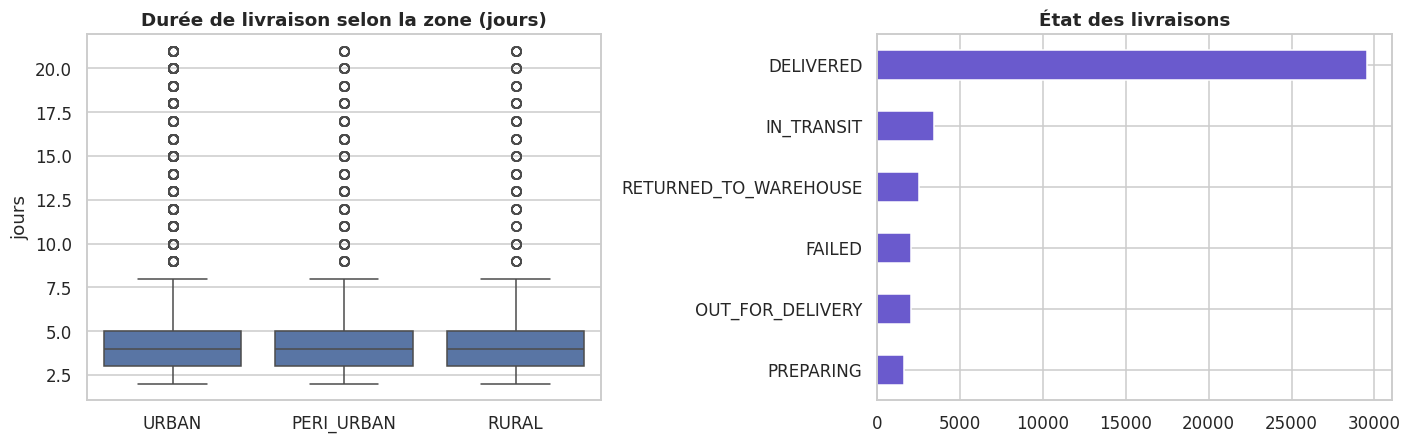

In [14]:
transp = deliveries.groupby("carrier").agg(
    livraisons=("delivery_id", "count"),
    echec_pct=("delivery_status", lambda s: 100 * (s == "FAILED").mean()),
    cout_moyen=("delivery_cost", "mean"),
)
transp["delai_median_jours"] = dl[dl["delivered_at"].notna()].groupby("carrier")["jours_commande_livraison"].median()
display(transp.sort_values("livraisons", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.boxplot(data=fait, x="delivery_address_zone", y="jours_commande_livraison", order=["URBAN", "PERI_URBAN", "RURAL"], ax=ax[0])
ax[0].set(title="Durée de livraison selon la zone (jours)", xlabel="", ylabel="jours")
deliveries["delivery_status"].value_counts().plot(kind="barh", ax=ax[1], color="slateblue"); ax[1].invert_yaxis()
ax[1].set(title="État des livraisons", ylabel="")
savefig("09_logistique")

**Ce qu'on retient :** la durée de livraison est **la même en ville, en périphérie et en zone rurale**, et les huit transporteurs affichent des performances quasi identiques (délai, taux d'échec, coût). Dans la réalité, la zone rurale est presque toujours plus lente : c'est un nouvel indice de données synthétiques.

### 4.6 Les clients

**Comment lire ces graphiques :** six petits graphiques qui décrivent la base clients (sans les clients en double).
- *Haut* : répartition par segment CRM (le classement fait par l'équipe marketing), par palier de fidélité et par statut de compte.
- *Bas* : répartition par âge, nombre d'inscriptions par trimestre, et nombre de commandes par client (« 0 » = ne jamais avoir commandé).

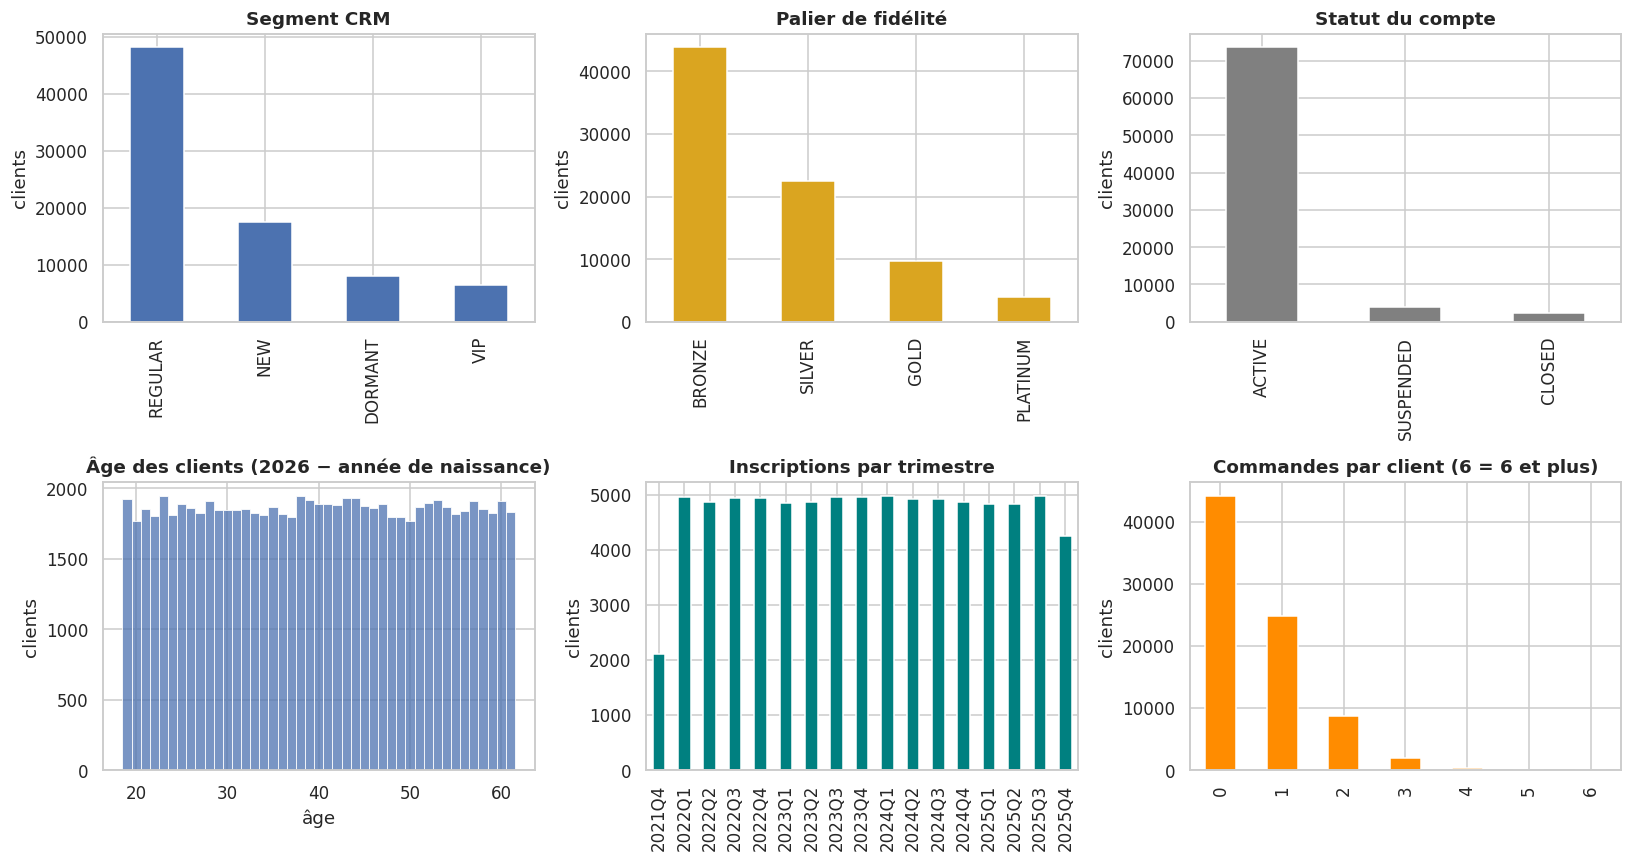

Clients distincts : 80 000 · comptes actifs : 92 % · âge de 19 à 61 ans
Clients n'ayant jamais commandé : 44 174 (55 %)
Commandes par client selon le segment CRM (moyenne) :


,commandes par client
DORMANT,0.62
NEW,0.63
REGULAR,0.62
VIP,0.63


In [15]:
cu = customers.drop_duplicates("email_hash").copy()
cu["age"] = 2026 - cu["birth_year"]
nb_commandes = orders_u.groupby("customer_id").size().reindex(cu["customer_id"]).fillna(0).astype(int)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
cu["customer_segment"].value_counts().plot(kind="bar", ax=ax[0, 0]); ax[0, 0].set(title="Segment CRM", xlabel="", ylabel="clients")
cu["loyalty_tier"].value_counts().reindex(["BRONZE", "SILVER", "GOLD", "PLATINUM"]).plot(kind="bar", ax=ax[0, 1], color="goldenrod"); ax[0, 1].set(title="Palier de fidélité", xlabel="", ylabel="clients")
cu["account_status"].value_counts().plot(kind="bar", ax=ax[0, 2], color="grey"); ax[0, 2].set(title="Statut du compte", xlabel="", ylabel="clients")
sns.histplot(cu["age"], discrete=True, ax=ax[1, 0]); ax[1, 0].set(title="Âge des clients (2026 − année de naissance)", xlabel="âge", ylabel="clients")
cu["registration_date"].dt.to_period("Q").astype(str).value_counts().sort_index().plot(kind="bar", ax=ax[1, 1], color="teal"); ax[1, 1].set(title="Inscriptions par trimestre", xlabel="", ylabel="clients")
nb_commandes.clip(upper=6).value_counts().sort_index().plot(kind="bar", ax=ax[1, 2], color="darkorange"); ax[1, 2].set(title="Commandes par client (6 = 6 et plus)", xlabel="", ylabel="clients")
savefig("10_clients")

jamais = (nb_commandes == 0)
print(f"Clients distincts : {fr(len(cu))} · comptes actifs : {100*(cu['account_status']=='ACTIVE').mean():.0f} % · âge de {int(cu['age'].min())} à {int(cu['age'].max())} ans")
print(f"Clients n'ayant jamais commandé : {fr(jamais.sum())} ({100*jamais.mean():.0f} %)")
print("Commandes par client selon le segment CRM (moyenne) :")
display(nb_commandes.groupby(cu.set_index("customer_id")["customer_segment"].reindex(cu["customer_id"]).values).mean().round(2).rename("commandes par client").to_frame())

**Ce qu'on retient :** la base compte environ 80 000 clients, en très grande majorité **actifs**, et la plupart sont **Régulier** et **Bronze**. Les inscriptions sont régulières d'un trimestre à l'autre. **Plus de la moitié des clients n'ont jamais commandé**, et ceux qui commandent le font le plus souvent une seule fois.

Un point important : les clients classés **VIP** commandent **autant** que les clients classés **Nouveau**, **Régulier** ou **Dormant** (environ 0,6 commande par client dans chaque segment). Autrement dit, le classement de l'équipe marketing **ne reflète pas l'activité réelle**. Nous devrons donc recalculer nos propres indicateurs de fidélité à partir des commandes.

## 5. À retenir

**Sur la qualité des données**

1. Les données sont **utilisables après nettoyage** : environ 98 % des articles et 99 % des commandes sont sains.
2. **Six problèmes prioritaires** (rouges dans le graphique de la partie 3) doivent être traités avant toute analyse : doublons de commandes, articles fantômes, totaux incohérents, paiements encaissés plusieurs fois, clients en double, identifiants clients partagés.
3. Les hash d'e-mail et de téléphone sont **trop courts** : il faudra les re-chiffrer avec un sel, comme l'exige le sujet.

**Sur l'activité**

4. L'activité est **stable** (environ 3 800 à 4 400 commandes par mois) et **très uniforme** entre pays, canaux, zones, catégories et transporteurs.
5. Cette uniformité est un **signal fort** : les données sont **synthétiques**. Les conclusions d'affaires (« le pays X préfère… ») ne sont **pas transposables à une vraie marketplace**, et les analyses doivent le mentionner.
6. Les classements CRM (segment, palier de fidélité) ne correspondent pas à l'activité observée : le **RFM** (score de fidélité calculé à partir de la récence, de la fréquence et du montant des achats) devra être recalculé depuis les commandes.

**Deux rappels éthiques du sujet** : la segmentation des clients ne doit **jamais** servir à exclure des personnes ni à fixer des prix de manière discriminatoire, et les analyses doivent mentionner les biais du jeu de données (forte part de zones urbaines, montants en devises non comparables).


Pour le détail technique complet (contrôles supplémentaires, règles de traitement, exports), voir le notebook **eda_profiling_afrishop.ipynb**.

## 6. Glossaire

| Terme | Explication simple |
|---|---|
| **Table / fichier CSV** | Un tableau de données, une ligne par « chose » (une commande, un client…). |
| **Doublon** | Une même ligne enregistrée plusieurs fois. |
| **Ligne orpheline** | Une ligne qui renvoie vers quelque chose qui n'existe pas (un article vers un produit absent du catalogue). |
| **Quarantaine** | Espace à part où l'on isole les lignes douteuses, sans les supprimer. |
| **Devise** | La monnaie : XOF (franc CFA), GHS (cedi ghanéen), NGN (naira nigérian). |
| **Médiane** | La valeur « du milieu » : la moitié des observations est en dessous, l'autre moitié au-dessus. |
| **Échelle logarithmique** | Échelle où chaque graduation vaut 10 fois la précédente ; utile quand les valeurs vont de très petites à très grandes. |
| **Mobile Money** | Paiement depuis un téléphone portable (Orange Money, Wave, MTN MoMo). |
| **COD (cash on delivery)** | Paiement en espèces à la livraison. |
| **CAPTURED / FAILED** | Paiement encaissé / paiement échoué. |
| **Hash** | Version chiffrée et irréversible d'une donnée personnelle (e-mail, téléphone) : on peut la comparer sans jamais la lire. |
| **Sel** | Texte secret ajouté avant le chiffrement pour rendre le hash impossible à deviner. |
| **RFM** | Score de fidélité client : Récence (dernier achat), Fréquence (nombre d'achats), Montant (argent dépensé). |
| **CRM** | Outil de gestion de la relation client, utilisé par l'équipe marketing (segments, paliers de fidélité). |
| **Données synthétiques** | Données fabriquées pour un exercice, qui imitent la réalité sans être réelles. |
| **UTC** | Heure de référence mondiale. |
| **Zone curated** | Étape du projet où les données sont nettoyées et rendues fiables. |